# Segmentación de clientes mediante clustering y análisis complementario con PCA

## Preparación, integración, modelado no supervisado e interpretación de perfiles

Este notebook documenta el proceso completo de construcción de una segmentación de clientes para **easyMoney** a partir de información sociodemográfica, comercial, de productos y de ventas. El objetivo es identificar perfiles homogéneos de comportamiento que permitan enriquecer la visión de negocio, complementar el análisis descriptivo del dashboard de Power BI y aportar una base analítica para futuras acciones de activación comercial, vinculación y rentabilidad.

### Objetivo del análisis
- Integrar distintas fuentes de información en una única base analítica.
- Preparar y transformar los datos para su explotación en técnicas de *clustering*.
- Construir una segmentación interpretable de la cartera mediante **K-Means**.
- Complementar el análisis con **PCA** para sintetizar la estructura subyacente de las variables.
- Traducir los resultados a una lectura de negocio útil para la toma de decisiones.

## 1. Preparación del entorno y librerías

En primer lugar se fija el entorno de trabajo y se importan las librerías necesarias para el tratamiento de datos, la visualización y la modelización no supervisada.

In [ ]:
!pip install --upgrade \
    "numpy==2.0.2" \
    "pandas==2.2.2" \
    "scipy==1.17.1" \
    "matplotlib>=3.10.8" \
    "scikit-learn==1.8.0" \
    "seaborn==0.13.2" \
    "jedi==0.19.2" \
    "pillow==11.0.0"\
    "setuptools==70.0.0"\
    --force-reinstall

!pip install "dython>=0.7.12" --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.7 MB/s eta 0:00:00
  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinu

  Using cached dython-0.7.12-py3-none-any.whl.metadata (3.4 kB)
  Attempting uninstall: dython
    Found existing installation: dython 0.7.10
    Uninstalling dython-0.7.10:
      Successfully uninstalled dython-0.7.10


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler, OrdinalEncoder

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 2. Carga de fuentes de datos

Se contemplan dos alternativas de carga: una orientada al trabajo en **Google Drive / Colab** y otra mediante rutas relativas locales, de forma que el notebook pueda adaptarse a distintos entornos de ejecución sin alterar la lógica analítica.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df_socio= pd.read_csv('/content/drive/MyDrive/datasets_TFM/customer_sociodemographics.csv')
df_comm= pd.read_csv('/content/drive/MyDrive/datasets_TFM/customer_commercial_activity.csv')
df_prod= pd.read_csv('/content/drive/MyDrive/datasets_TFM/customer_products.csv')
df_prod_desc= pd.read_csv('/content/drive/MyDrive/datasets_TFM/product_description.csv')
df_sales= pd.read_csv('/content/drive/MyDrive/datasets_TFM/sales.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_prod = pd.read_csv("../DatasetsTFM/customer_products.csv")
df_socio = pd.read_csv("../DatasetsTFM/customer_sociodemographics.csv")
df_comm = pd.read_csv("../DatasetsTFM/customer_commercial_activity.csv")
df_sales = pd.read_csv("../DatasetsTFM/sales.csv")
df_prod_desc = pd.read_csv("../DatasetsTFM/product_description.csv")

## 3. Limpieza inicial y depuración de columnas

Antes de iniciar la integración, se eliminan columnas residuales o generadas automáticamente en exportaciones previas (por ejemplo, campos `Unnamed`) para asegurar consistencia estructural entre tablas.

In [ ]:
def limpiar_columnas_basura(df):
    cols_to_drop = [c for c in df.columns if 'Unnamed' in c]
    if cols_to_drop:
        print(f"🗑️ Eliminando columnas basura: {cols_to_drop}")
        df.drop(columns=cols_to_drop, inplace=True)
    return df

df_prod = limpiar_columnas_basura(df_prod)
df_socio = limpiar_columnas_basura(df_socio)
df_comm = limpiar_columnas_basura(df_comm)
df_sales = limpiar_columnas_basura(df_sales)
df_prod_desc = limpiar_columnas_basura(df_prod_desc)

🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']


In [ ]:
# SQL Equivalente:
# SELECT s.*, d.product_desc
# FROM sales s
# LEFT JOIN product_description d ON s.product_ID = d.pk_product_ID;

# En Pandas:
df_ventas_enriquecida = pd.merge(
    df_sales,
    df_prod_desc,
    left_on='product_ID',
    right_on='pk_product_ID',
    how='left'
)

In [ ]:
# SQL Equivalente:
# SELECT * FROM sociodemo s
# JOIN commercial c ON s.pk_cid = c.pk_cid AND s.pk_partition = c.pk_partition

# En Pandas:
df_master = pd.merge(
    df_socio,
    df_comm,
    on=['pk_cid', 'pk_partition'],
    how='inner',
    validate='1:1'
)

## 4. Integración y enriquecimiento de tablas

En este bloque se consolida la información sociodemográfica, comercial, de productos y de ventas en un único dataframe maestro. La lógica de unión se plantea a nivel de cliente y partición temporal, preservando la trazabilidad del dato.

In [ ]:
# Fusionamos df_prod al df_master que ya tienes
df_master = pd.merge(
    df_master,
    df_prod,
    on=['pk_cid', 'pk_partition'],
    how='inner',
    validate='1:1'
)

In [ ]:
df_ventas_enriquecida['month_sale_join'] = pd.to_datetime(df_ventas_enriquecida['month_sale']).dt.strftime('%Y-%m')

df_master_t = pd.merge(
    df_master,
    df_ventas_enriquecida,
    left_on=['pk_cid', 'pk_partition'],
    right_on=['cid', 'month_sale_join'],
    how='left'
)

## 5. Tratamiento de nulos y normalización de variables

Una vez integrado el dataset, se procede a homogeneizar categorías, imputar valores faltantes mediante reglas de negocio y preparar variables clave para su uso posterior en el modelo. Este paso resulta crítico para evitar sesgos y garantizar comparabilidad.

In [ ]:
df_master_t = df_master_t.sort_values(by=['pk_cid', 'pk_partition'])

# Ajustamos region_code y country_id
df_master_t['country_id'] = df_master_t['country_id'].mask(df_master_t['country_id'] != 'ES', 'Other')
df_master_t['region_code'] = df_master_t['region_code'].mask(df_master_t['country_id'] == 'Other', -1.0)

# Rellenamos segment
# 1. Definimos los mapeos
# Mapeo de texto a número (Ordinal)
segment_to_num = {
    '03 - UNIVERSITARIO': 1,
    '02 - PARTICULARES': 2,
    '01 - TOP': 3
}

# Mapeo inverso (de número a texto)
num_to_segment = {v: k for k, v in segment_to_num.items()}

# 2. Aplicar el mapeo a la columna (nan se mantiene como nan)
df_master_t['segment_num'] = df_master_t['segment'].map(segment_to_num).astype(float)

group_cols = ['salary', 'region_code', 'age']
target_col = 'segment_num'
group_median_seg = df_master_t.groupby(group_cols)[target_col].transform('median')
df_master_t[target_col] = df_master_t[target_col].fillna(group_median_seg)
global_fallback = df_master_t[target_col].median()
df_master_t[target_col] = df_master_t[target_col].fillna(global_fallback)

# 3. Devolver a texto cuando termines
df_master_t['segment'] = df_master_t['segment_num'].map(num_to_segment).astype('object')

# Rellenamos salary
group_cols = ['segment', 'region_code']
target_col = 'salary'
group_median_sal = df_master_t.groupby(group_cols)[target_col].transform('median')
df_master_t[target_col] = df_master_t[target_col].fillna(group_median_sal)
global_fallback = df_master_t[target_col].median()
df_master_t[target_col] = df_master_t[target_col].fillna(global_fallback)

group_cols = ['segment']
target_col = 'entry_channel'
group_median_enc = df_master_t.groupby(group_cols)[target_col].transform( # Para usar la moda toca hacer un apaño
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)
df_master_t[target_col] = df_master_t[target_col].fillna(group_median_enc)
global_fallback = df_master_t[target_col].mode()[0]
df_master_t[target_col] = df_master_t[target_col].fillna(global_fallback)

df_master.entry_channel.isnull().sum() - df_master_t.entry_channel.isnull().sum()

mode_value_region_code=df_master_t["region_code"].mode()[0]
mode_value_gender=df_master_t["gender"].mode()[0]
mode_value_entry_channel=df_master_t["entry_channel"].mode()[0]
mode_value_segment=df_master_t["segment"].mode()[0]
moda_payroll = df_master_t['payroll'].mode()[0]
moda_pension_plan = df_master_t['pension_plan'].mode()[0]

df_master_t["region_code"] = df_master_t["region_code"].fillna(mode_value_region_code)
df_master_t["gender"] = df_master_t["gender"].fillna(mode_value_gender)
df_master_t["entry_channel"] = df_master_t["entry_channel"].fillna(mode_value_entry_channel)
df_master_t["segment"] = df_master_t["segment"].fillna(mode_value_segment)
df_master_t['payroll'] = df_master_t['payroll'].fillna(moda_payroll)
df_master_t['pension_plan'] = df_master_t['pension_plan'].fillna(moda_pension_plan)

df_master_t.isnull().sum()

,0
pk_cid,0
pk_partition,0
country_id,0
region_code,0
gender,0
age,0
deceased,0
salary,0
entry_date,0
entry_channel,0


In [ ]:
cols_to_drop = ['cid', 'month_sale', 'pk_product_ID', 'family_product', 'product_desc', 'month_sale_join']
df_master_t = df_master_t.drop(columns=cols_to_drop)

# cols_to_drop = ['pk_cid', 'pk_partition', 'country_id', 'deceased', 'entry_date',
#                 'pk_sale', 'product_ID', 'pk_product_ID', 'product_desc', 'family_product']
# También podríamos quitar 'active_customer'? Depende, pero la dejamos por ahora

# X = df_master_t.drop(columns=cols_to_drop + ['target'])

In [ ]:
df_master_t.drop('em_account_p', axis=1, inplace=True)
df_master_t.drop('em_account_pp', axis=1, inplace=True)

In [ ]:
df_master_t.entry_date = pd.to_datetime(df_master_t.entry_date)
df_master_t.pk_partition = pd.to_datetime(df_master_t.pk_partition)

df_master_t['antiguedad_meses'] = (
    (df_master_t['pk_partition'].dt.year - df_master_t['entry_date'].dt.year) * 12 +
    (df_master_t['pk_partition'].dt.month - df_master_t['entry_date'].dt.month)
)

In [ ]:
df_master_t

,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary,entry_date,entry_channel,...,pension_plan,payroll_account,emc_account,debit_card,em_acount,pk_sale,product_ID,net_margin,segment_num,antiguedad_meses
1491145,15891,2018-07-01,ES,28.0,H,59,N,136054.71,2018-07-01,KAT,...,0.0,0,0,0,1,130004.0,4657.0,66.4,1.0,0
2184939,15891,2018-08-01,ES,28.0,H,59,N,115981.86,2018-07-01,KAT,...,0.0,0,0,0,0,NaN,NaN,NaN,2.0,1
2984461,16063,2018-11-01,ES,28.0,H,62,N,136054.71,2018-11-01,KAT,...,0.0,0,0,0,0,NaN,NaN,NaN,1.0,0
3653273,16063,2018-12-01,ES,28.0,H,62,N,115981.86,2018-11-01,KAT,...,0.0,0,0,0,0,NaN,NaN,NaN,2.0,1
4056697,16063,2019-01-01,ES,28.0,H,62,N,115981.86,2018-11-01,KAT,...,0.0,0,0,0,0,NaN,NaN,NaN,2.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5716611,1553685,2019-05-01,ES,13.0,V,52,N,60127.95,2019-05-01,KHE,...,0.0,0,0,0,0,NaN,NaN,NaN,1.0,0
5716610,1553686,2019-05-01,ES,41.0,H,30,N,87387.63,2019-05-01,KHE,...,0.0,0,0,0,0,NaN,NaN,NaN,1.0,0
5716609,1553687,2019-05-01,ES,28.0,V,21,N,136054.71,2019-05-01,KHE,...,0.0,0,0,0,0,NaN,NaN,NaN,1.0,0
5716608,1553688,2019-05-01,ES,39.0,H,43,N,88929.84,2019-05-01,KHE,...,0.0,0,0,0,0,NaN,NaN,NaN,1.0,0


In [ ]:
df_master_t = df_master_t.sort_values(by=['pk_partition', 'pk_cid'])

In [ ]:
df_prod_desc

,pk_product_ID,product_desc,family_product
0,4657,em_acount,account
1,3819,debit_card,payment_card
2,1364,pension_plan,pension_plan
3,2234,payroll,account
4,2235,payroll_account,account
5,8871,emc_account,account
6,2312,credit_card,payment_card
7,2335,short_term_deposit,investment
8,2336,long_term_deposit,investment
9,2673,securities,investment


In [ ]:
df_comm

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment
0,1375586,2018-01,2018-01,KHL,1.0,02 - PARTICULARES
1,1050611,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO
2,1050612,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO
3,1050613,2018-01,2015-08,KHD,0.0,03 - UNIVERSITARIO
4,1050614,2018-01,2015-08,KHE,1.0,03 - UNIVERSITARIO
...,...,...,...,...,...,...
5962919,1166765,2019-05,2016-08,KHE,0.0,03 - UNIVERSITARIO
5962920,1166764,2019-05,2016-08,KHE,0.0,03 - UNIVERSITARIO
5962921,1166763,2019-05,2016-08,KHE,1.0,02 - PARTICULARES
5962922,1166789,2019-05,2016-08,KHE,0.0,03 - UNIVERSITARIO


In [ ]:
df_socio

,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary
0,1375586,2018-01,ES,29.0,H,35,N,87218.10
1,1050611,2018-01,ES,13.0,V,23,N,35548.74
2,1050612,2018-01,ES,13.0,V,23,N,122179.11
3,1050613,2018-01,ES,50.0,H,22,N,119775.54
4,1050614,2018-01,ES,50.0,V,23,N,NaN
...,...,...,...,...,...,...,...,...
5962919,1166765,2019-05,ES,50.0,V,22,N,43912.17
5962920,1166764,2019-05,ES,26.0,V,23,N,23334.99
5962921,1166763,2019-05,ES,50.0,H,47,N,NaN
5962922,1166789,2019-05,ES,50.0,H,22,N,199592.82


In [ ]:
df_master_t[df_master_t['pk_cid'] == 1465864]


,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary,entry_date,entry_channel,...,pension_plan,payroll_account,emc_account,debit_card,em_acount,pk_sale,product_ID,net_margin,segment_num,antiguedad_meses
2804557,1465864,2018-10-01,ES,3.0,V,30,N,61886.94,2018-09-01,KHM,...,0.0,0,0,0,0,NaN,NaN,NaN,2.0,1
3032322,1465864,2018-11-01,ES,3.0,V,30,N,61886.94,2018-09-01,KHM,...,0.0,0,0,0,0,NaN,NaN,NaN,2.0,2
3659216,1465864,2018-12-01,ES,3.0,V,30,N,61886.94,2018-09-01,KHM,...,0.0,0,0,0,0,NaN,NaN,NaN,2.0,3
3838184,1465864,2019-01-01,ES,3.0,V,30,N,61886.94,2018-09-01,KHM,...,0.0,0,0,0,0,NaN,NaN,NaN,2.0,4
4395743,1465864,2019-02-01,ES,3.0,V,30,N,61886.94,2018-09-01,KHM,...,0.0,0,0,0,0,NaN,NaN,NaN,2.0,5
4773977,1465864,2019-03-01,ES,3.0,V,30,N,61886.94,2018-09-01,KHM,...,0.0,0,0,0,0,NaN,NaN,NaN,2.0,6
5382729,1465864,2019-04-01,ES,3.0,V,31,N,61886.94,2018-09-01,KHM,...,0.0,0,0,0,1,200891.0,4657.0,62.1,2.0,7
5769590,1465864,2019-05-01,ES,3.0,V,31,N,61886.94,2018-09-01,KHM,...,1.0,1,1,1,0,38363.0,2234.0,75.6,2.0,8
5769591,1465864,2019-05-01,ES,3.0,V,31,N,61886.94,2018-09-01,KHM,...,1.0,1,1,1,0,57578.0,1364.0,8466.3,2.0,8
5769592,1465864,2019-05-01,ES,3.0,V,31,N,61886.94,2018-09-01,KHM,...,1.0,1,1,1,0,75313.0,2235.0,54.9,2.0,8


In [ ]:
# Limpiamos el dataset
df_master_t['deceased'].value_counts()



,count
deceased,
N,5999927
S,1076


In [ ]:
df_master_t = df_master_t[df_master_t['deceased'] != 'S']


In [ ]:
df_master_t['active_customer'].value_counts()

,count
active_customer,
0.0,3557971
1.0,2441956


## 6. Variables derivadas para segmentación

Se generan variables auxiliares que sintetizan el comportamiento del cliente, especialmente en relación con la actividad, la compra y el uso de familias de producto. Estas variables permiten trasladar la lógica transaccional a una representación más útil para *clustering*.

In [ ]:
# product_id_selected = 1364.0

# df_master_t['has_sale'] = np.where(

# df_master_t['pk_sale'].isna() | (df_master_t['pk_sale'].astype(str).str.strip().isin(['0', ''])) & (df_master_t['product_ID'] == product_id_selected ),

# 0, 1

# )

In [ ]:
df_master_t['has_sale'] = np.where(

df_master_t['pk_sale'].isna() | (df_master_t['pk_sale'].astype(str).str.strip().isin(['0', ''])),
0, 1
)

In [ ]:
gender_to_num = {
    'H': 1,
    'V': 0
}


# 2. Aplicar el mapeo a la columna (nan se mantiene como nan)
df_master_t['gender_num'] = df_master_t['gender'].map(gender_to_num).astype(float)

In [ ]:
df_prod_desc

,pk_product_ID,product_desc,family_product
0,4657,em_acount,account
1,3819,debit_card,payment_card
2,1364,pension_plan,pension_plan
3,2234,payroll,account
4,2235,payroll_account,account
5,8871,emc_account,account
6,2312,credit_card,payment_card
7,2335,short_term_deposit,investment
8,2336,long_term_deposit,investment
9,2673,securities,investment


In [ ]:
print(df_ventas_enriquecida.groupby(['family_product','product_desc'])['net_margin'].agg(['mean', 'count', 'sum']).sort_values(ascending=False, by='mean'))


                                          mean   count          sum
family_product product_desc                                        
pension_plan   pension_plan        5976.435908   19369  115757587.1
loan           mortgage            2532.510000      10      25325.1
               loans               2183.924000      25      54598.1
investment     funds               1499.047159     880    1319161.5
               securities          1497.833362    1157    1732993.2
               long_term_deposit   1496.919186    4227    6327477.4
               short_term_deposit  1486.431322    4441    6601241.5
account        emc_account           70.012927   12323     862769.3
               em_acount             69.973792  117435    8217372.3
               payroll_account       69.968785   18110    1267134.7
               payroll               69.933216   18750    1311247.8
payment_card   credit_card           60.016020    5206     312443.4
               debit_card            60.003216  

In [ ]:
# 1. Preparar la estructura de familias
families = df_prod_desc.groupby('family_product')['product_desc'].apply(list).to_dict()

# Añadimos manualmente los extras que mencionaste antes si no están en el DF
if 'account' in families:
    families['account'].extend(['em_account_p', 'em_account_pp'])

for family, products in families.items():
    # Solo usamos los productos que realmente existan como columnas en el DF
    cols_present = [p for p in products if p in df_master_t.columns]

    if not cols_present:
        continue

    # A. Columna de USO: Suma de cuántos productos de esa familia tiene el cliente
    # (Asumiendo que las columnas de producto tienen 1 si lo usa y 0 si no)
    df_master_t[f'family_{family}_use'] = df_master_t[cols_present].sum(axis=1)

    # B. Columna de COMPRA (Venta Neta): 1 si ha comprado algún producto de la familia
    # Usamos 'has_sale' y comprobamos si el ID del producto vendido pertenece a esta familia
    # Primero obtenemos los IDs de esta familia
    family_ids = df_prod_desc[df_prod_desc['family_product'] == family]['pk_product_ID'].unique()

    # Marcamos como 1 si hubo venta (has_sale==1) Y el ID está en la familia
    df_master_t[f'family_{family}_purchase'] = (
        (df_master_t['has_sale'] == 1) &
        (df_master_t['product_ID'].isin(family_ids))
    ).astype(int)

# 2. Limpieza opcional: si un cliente tiene 'use' pero no 'purchase', es stock;
# si tiene 'purchase' es que acaba de contratarlo en este registro.


In [ ]:
df_master_t.columns

Index(['pk_cid', 'pk_partition', 'country_id', 'region_code', 'gender', 'age',
       'deceased', 'salary', 'entry_date', 'entry_channel', 'active_customer',
       'segment', 'short_term_deposit', 'loans', 'mortgage', 'funds',
       'securities', 'long_term_deposit', 'credit_card', 'payroll',
       'pension_plan', 'payroll_account', 'emc_account', 'debit_card',
       'em_acount', 'pk_sale', 'product_ID', 'net_margin', 'segment_num',
       'antiguedad_meses', 'has_sale', 'gender_num', 'family_account_use',
       'family_account_purchase', 'family_investment_use',
       'family_investment_purchase', 'family_loan_use', 'family_loan_purchase',
       'family_payment_card_use', 'family_payment_card_purchase',
       'family_pension_plan_use', 'family_pension_plan_purchase'],
      dtype='object')

## 7. Construcción del dataset cliente a cliente

Dado que el objetivo del modelo es segmentar clientes y no registros mensuales, se agregan las observaciones a nivel de `pk_cid`. Se define una batería de reglas de agregación con criterios diferenciados según la naturaleza de cada variable.

In [ ]:
# Selección con corchetes dobles
cols = [
    'family_account_use', 'family_account_purchase',
    'family_investment_use', 'family_investment_purchase',
    'family_loan_use', 'family_loan_purchase',
    'family_payment_card_use', 'family_payment_card_purchase',
    'family_pension_plan_use', 'family_pension_plan_purchase'
]

# Para ver las primeras filas y comprobar que hay datos
print(df_master_t[cols].head())

# Para ver cuántos clientes han comprado/usado cada familia
for col in cols:
    print(f"\n--- Value Counts de {col} ---")
    print(df_master_t[col].value_counts().head(10))


        family_account_use  family_account_purchase  family_investment_use  \
237929                 1.0                        0                      1   
237930                 1.0                        0                      0   
237928                 2.0                        0                      0   
237926                 1.0                        0                      0   
237921                 0.0                        0                      0   

        family_investment_purchase  family_loan_use  family_loan_purchase  \
237929                           0                0                     0   
237930                           0                0                     0   
237928                           0                0                     0   
237926                           0                0                     0   
237921                           0                0                     0   

        family_payment_card_use  family_payment_card_purchase  \
237

In [ ]:
# Agrupación
df_master_t['family_financiacion'] = df_master_t[['loans', 'mortgage', 'credit_card']].sum(axis=1)
df_master_t['family_inversion'] = df_master_t[['funds', 'securities', 'short_term_deposit', 'long_term_deposit', 'pension_plan']].sum(axis=1)
df_master_t['family_cuentas_dia_dia'] = df_master_t[['em_acount', 'emc_account', 'payroll_account', 'payroll', 'debit_card']].sum(axis=1)

In [ ]:
# 1. Definimos las reglas de agregación en una sola estructura
# Aquí decides qué columnas colapsar y cómo:
# 'sum' -> suma total
# 'max' -> valor más alto alcanzado
# lambda x: (x > 0).any().astype(int) -> 1 si tuvo algún positivo, 0 si no

agg_rules = {
    'has_sale': 'sum',
    'antiguedad_meses': 'last',
    'age': 'last',
    'gender_num': 'last',
    'segment_num': 'max',
    'family_account_purchase': 'sum',
    'family_investment_purchase': 'sum',
    'family_loan_purchase': 'sum',
    'family_payment_card_purchase': 'sum',
    'family_pension_plan_purchase': 'sum',
    # 'net_margin': 'sum',
    'active_customer': 'sum',
}

# 2. Ejecutamos el colapso en una sola línea
df_segmentacion = df_master_t.groupby('pk_cid').agg(agg_rules).reset_index()

# Ver el resultado
print(df_segmentacion.head())

   pk_cid  has_sale  antiguedad_meses  age  gender_num  segment_num  \
0   15891         1                 1   59         1.0          2.0   
1   16063         0                 6   62         1.0          2.0   
2   16203         1                 5   70         0.0          3.0   
3   16502         2                 8   58         1.0          2.0   
4   17457         1                20   54         1.0          2.0   

   family_account_purchase  family_investment_purchase  family_loan_purchase  \
0                        1                           0                     0   
1                        0                           0                     0   
2                        1                           0                     0   
3                        2                           0                     0   
4                        0                           0                     0   

   family_payment_card_purchase  family_pension_plan_purchase  active_customer  
0          

In [ ]:
df_segmentacion.isnull().sum()

,0
pk_cid,0
has_sale,0
antiguedad_meses,0
age,0
gender_num,0
segment_num,0
family_account_purchase,0
family_investment_purchase,0
family_loan_purchase,0
family_payment_card_purchase,0


## 8. Clusterización y selección del número de grupos

Con el dataset analítico ya consolidado, se ejecuta el proceso de clusterización mediante **K-Means**. Se exploran distintos valores de `k` y se combinan criterios cuantitativos y de interpretabilidad para seleccionar una partición útil desde el punto de vista de negocio.

# **Clusterización**

In [ ]:
df_segmentacion_n = df_segmentacion.copy()
try : df_segmentacion_n['salary'] = np.log1p(df_segmentacion_n['salary'])
except KeyError: print("La columna 'salary' no existe en df_segmentacion_n, omitiendo transformación logarítmica.")

La columna 'salary' no existe en df_segmentacion_n, omitiendo transformación logarítmica.


In [ ]:
X = df_segmentacion_n.drop(columns=['pk_cid']).copy()

In [ ]:
X

,has_sale,antiguedad_meses,age,gender_num,segment_num,family_account_purchase,family_investment_purchase,family_loan_purchase,family_payment_card_purchase,family_pension_plan_purchase,active_customer
0,1,1,59,1.0,2.0,1,0,0,0,0,1.0
1,0,6,62,1.0,2.0,0,0,0,0,0,5.0
2,1,5,70,0.0,3.0,1,0,0,0,0,5.0
3,2,8,58,1.0,2.0,2,0,0,0,0,8.0
4,1,20,54,1.0,2.0,0,0,0,1,0,17.0
...,...,...,...,...,...,...,...,...,...,...,...
456313,0,0,52,0.0,1.0,0,0,0,0,0,0.0
456314,0,0,30,1.0,1.0,0,0,0,0,0,0.0
456315,0,0,21,0.0,1.0,0,0,0,0,0,0.0
456316,0,0,43,1.0,1.0,0,0,0,0,0,0.0


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

clustering_pipeline = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('kmeans', KMeans(random_state=42, n_init=30))
])

print("Pipeline de clustering definido con éxito:")
print(clustering_pipeline)

Pipeline de clustering definido con éxito:
Pipeline(steps=[('kmeans', KMeans(n_init=30, random_state=42))])


Fitting pipe with 2 clusters
Fitting pipe with 3 clusters
Fitting pipe with 4 clusters
Fitting pipe with 5 clusters
Fitting pipe with 6 clusters
Fitting pipe with 7 clusters
Fitting pipe with 8 clusters
Fitting pipe with 9 clusters
Fitting pipe with 10 clusters
Fitting pipe with 11 clusters
Fitting pipe with 12 clusters
Fitting pipe with 13 clusters
Fitting pipe with 14 clusters


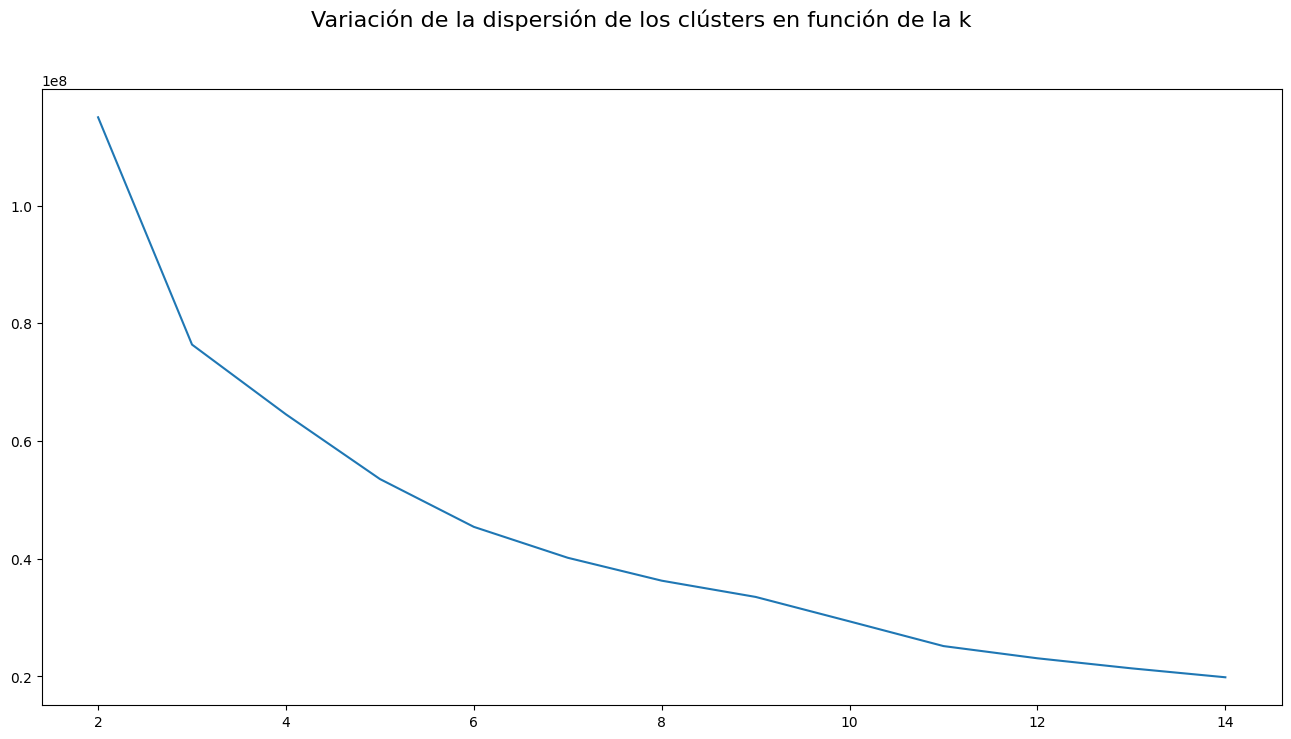

In [ ]:
sse = {}

for k in range(2, 15):
    print(f"Fitting pipe with {k} clusters")

    clustering_model = KMeans(n_clusters=k, random_state = 42)
    clustering_model.fit(X)

    sse[k] = clustering_model.inertia_

fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot()

x_values = list(sse.keys())
y_values = list(sse.values())

ax.plot(x_values, y_values, label="Inertia/dispersión de los clústers")
fig.suptitle(
    "Variación de la dispersión de los clústers en función de la k", fontsize=16
);

In [ ]:
# 1. Normalizamos para que el cálculo de ángulos sea justo (0 a 1)
x_norm = (np.array(x_values) - min(x_values)) / (max(x_values) - min(x_values))
y_norm = (np.array(y_values) - min(y_values)) / (max(y_values) - min(y_values))

# 2. Calculamos las pendientes (derivada discreta) entre puntos consecutivos
# dy/dx
pendientes = np.diff(y_norm) / np.diff(x_norm)

# 3. Buscamos el primer punto donde la pendiente es mayor a -1 (45º hacia abajo)
# Nota: La inercia siempre baja, por lo que buscamos cuando la pendiente sube de -1 hacia 0
k_optimal = None
for i, p in enumerate(pendientes):
    if p > -1: # -1 equivale a una inclinación de 45º descendente
        k_optimal = x_values[i]
        break

print(f"El k óptimo detectado por inclinación es: {k_optimal}")

El k óptimo detectado por inclinación es: 6


In [ ]:
# -----------------------------
# Entrenamiento final
# -----------------------------
# k_optimal = 5

# Actualizar número de clusters de forma segura
clustering_pipeline.set_params(kmeans__n_clusters=k_optimal)

# Entrenar pipeline completo
clustering_pipeline.fit(X)

# Obtener etiquetas
cluster_labels = clustering_pipeline.predict(X)

# Añadir clusters al dataset
X_with_clusters = X.copy()
X_with_clusters['cluster'] = cluster_labels

print(f"Clusters asignados a {X_with_clusters.shape[0]} clientes con k={k_optimal}.")
display(X_with_clusters.head())


Clusters asignados a 456318 clientes con k=6.


,has_sale,antiguedad_meses,age,gender_num,segment_num,family_account_purchase,family_investment_purchase,family_loan_purchase,family_payment_card_purchase,family_pension_plan_purchase,active_customer,cluster
0,1,1,59,1.0,2.0,1,0,0,0,0,1.0,0
1,0,6,62,1.0,2.0,0,0,0,0,0,5.0,0
2,1,5,70,0.0,3.0,1,0,0,0,0,5.0,0
3,2,8,58,1.0,2.0,2,0,0,0,0,8.0,0
4,1,20,54,1.0,2.0,0,0,0,1,0,17.0,0


In [ ]:
# -----------------------------
# Perfilado de clusters
# -----------------------------

# Tamaño de cada cluster
cluster_sizes = (
    X_with_clusters['cluster']
    .value_counts()
    .sort_index()
    .to_frame(name='count_customers')
)

# Variables que se agregan por MEDIANA
# median_vars = [
#     # 'segment_num',
#     'gender_num'
# ]

# median_df = (
#     X_with_clusters
#     .groupby('cluster')[median_vars]
#     .median()
# )

# Variables que se agregan por MEDIA
mean_vars = [
    # 'salary',
    'has_sale',
    'active_customer',
    'antiguedad_meses',
    'age',
    # 'net_margin',
    'segment_num',
    # 'family_financiacion',
    # 'family_inversion',
    # 'family_cuentas_dia_dia',
    'family_account_purchase',
    'family_investment_purchase',
    'family_loan_purchase',
    'family_payment_card_purchase',
    'family_pension_plan_purchase',
    'gender_num'

]

means_df = (
    X_with_clusters
    .groupby('cluster')[mean_vars]
    .mean()
)

means_df.columns = [f"{col}_mean" for col in means_df.columns]

# Unión final
# cluster_profile_df = pd.concat(
#     [cluster_sizes, median_df, means_df],
#     axis=1
# )

cluster_profile_df = pd.concat(
    [cluster_sizes, means_df],
    axis=1
)


cluster_profile_df


,count_customers,has_sale_mean,active_customer_mean,antiguedad_meses_mean,age_mean,segment_num_mean,family_account_purchase_mean,family_investment_purchase_mean,family_loan_purchase_mean,family_payment_card_purchase_mean,family_pension_plan_purchase_mean,gender_num_mean
cluster,,,,,,,,,,,,
0,49734,1.196908,5.641855,9.495013,50.817167,2.027768,0.796236,0.129790,0.000101,0.201532,0.069248,0.430108
1,84903,0.170877,4.754131,43.971285,27.285420,1.212007,0.082188,0.003416,0.000071,0.055993,0.029210,0.534198
2,63459,0.782852,16.348256,24.862651,28.404151,1.425787,0.396256,0.026395,0.000268,0.232623,0.127311,0.492554
3,110968,0.899638,2.963287,7.058035,24.235059,1.276562,0.780883,0.008552,0.000018,0.077878,0.032307,0.521880
4,32792,0.391681,10.945414,36.521194,54.378751,2.088894,0.171078,0.039369,0.000152,0.137046,0.044035,0.433093
5,114462,0.038117,0.284182,25.545692,24.727106,1.115610,0.022846,0.000393,0.000000,0.011943,0.002935,0.556473


In [ ]:
# 1. Crear el mapeo {pk_cid: cluster} a partir de los resultados del modelo
# Asumiendo que df_segmentacion y cluster_labels ya existen y están alineados
cluster_mapping = dict(zip(df_segmentacion['pk_cid'], cluster_labels))

# 2. Mapear el cluster a la tabla original (mes a mes)
# Ojo: esto asigna el cluster a TODAS las filas de ese cliente
df_master_t['cluster'] = df_master_t['pk_cid'].map(cluster_mapping)

# 3. Definir reglas de agregación para el perfilado.
# AQUÍ ES DONDE AÑADES LIBREMENTE VARIABLES, se hayan usado o no en K-Means.
viz_agg_rules = {
    # 1. Demografía y Contexto (¿Quiénes son?)
    'age': 'mean',                 # ¿Jóvenes estudiantes, millenials, o jubilados?
    'gender_num': 'mean',          # Por si hubiera un sesgo de género fuerte en algún nicho
    'antiguedad_meses': 'mean',    # ¿Son recién llegados o veteranos leales?

    # 2. Valor y Rentabilidad (¿Qué le aportan al banco?)
    'salary': 'mean',              # Capacidad adquisitiva
    'net_margin': 'mean',          # El valor real que nos dejan en caja
    'active_customer': 'mean',     # ¿Usan el banco o somos una cuenta fantasma/secundaria?
    'has_sale': 'mean',            # ¿Son propensos a comprar nuevos productos?

    # 3. Comportamiento por Familias (¿Qué tipo de necesidades tienen?)
    'family_account_purchase': 'mean',
    'family_investment_purchase': 'mean', # Clave para detectar perfiles "Inversores"
    'family_loan_purchase': 'mean',       # Clave para perfiles "Buscadores de crédito"
    'family_payment_card_purchase': 'mean',
    'family_pension_plan_purchase': 'mean', # Clave para perfiles "Previsores/Senior"

    # 4. Productos Ancla (¿Tienen ataduras fuertes?)
    # Usamos 'mean' porque al ser 0 o 1, nos dará el % de penetración en el clúster.
    'payroll': 'mean',             # Tener la nómina domiciliada cambia por completo el perfil
    'mortgage': 'mean',            # Hipotecados (baja probabilidad de fuga, alto LTV)
    'credit_card': 'mean',         # Consumo a crédito vs débito
}

# 4. Calcular los promedios por cluster
# Al calcular la media sobre la tabla original, estamos calculando
# la "media mensual por cliente en el cluster"
cluster_profile_means = df_master_t.groupby('cluster').agg(viz_agg_rules)

# 5. Renombrar columnas para que coincidan con tu formato deseado (añadiendo '_mean')
cluster_profile_means.columns = [f"{col}_mean" for col in cluster_profile_means.columns]

# 6. Calcular el número ÚNICO de clientes por cluster
# Es vital usar nunique() sobre pk_cid porque df_master_t tiene varias filas por cliente
cluster_sizes = (
    df_master_t.groupby('cluster')['pk_cid']
    .nunique()
    .to_frame(name='count_customers')
)

# 7. Unir todo en el dataframe final
cluster_profile_final = pd.concat(
    [cluster_sizes, cluster_profile_means],
    axis=1
)

# Mostrar el resultado final
display(cluster_profile_final)

,count_customers,age_mean,gender_num_mean,antiguedad_meses_mean,salary_mean,net_margin_mean,active_customer_mean,has_sale_mean,family_account_purchase_mean,family_investment_purchase_mean,family_loan_purchase_mean,family_payment_card_purchase_mean,family_pension_plan_purchase_mean,payroll_mean,mortgage_mean,credit_card_mean
cluster,,,,,,,,,,,,,,,,
0,49734,50.621701,0.433193,7.309776,108533.421918,563.137645,0.611997,0.129834,0.086371,0.014079,0.000011,0.021861,0.007512,0.058082,0.000076,0.012973
1,84903,26.598598,0.538380,36.393350,111999.843155,1105.852950,0.299230,0.010755,0.005173,0.000215,0.000004,0.003524,0.001838,0.029672,0.000048,0.010578
2,63459,27.835636,0.492683,17.022148,108293.237201,1075.985193,0.963328,0.046130,0.023350,0.001555,0.000016,0.013707,0.007502,0.099999,0.000075,0.020178
3,110968,23.377829,0.527915,4.084837,102590.323830,296.144087,0.370569,0.112503,0.097652,0.001069,0.000002,0.009739,0.004040,0.022039,0.000003,0.001077
4,32792,53.708695,0.434421,28.958966,120977.315793,874.599346,0.698315,0.024989,0.010915,0.002512,0.000010,0.008743,0.002809,0.081816,0.000304,0.057072
5,114462,24.110362,0.558470,18.444938,108456.889735,525.698739,0.018975,0.002545,0.001525,0.000026,0.000000,0.000797,0.000196,0.000918,0.000000,0.000095


## 9. Perfilado e interpretación de los clústeres

Una vez asignados los grupos, se amplía el análisis con variables de perfilado que no necesariamente forman parte directa del entrenamiento, pero sí aportan valor para la lectura de negocio. El objetivo no es solo agrupar, sino **explicar** qué representa cada segmento.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

# ==========================================
# 1. AGREGACIÓN MAESTRA (K-Means + Perfilado)
# ==========================================
agg_rules = {
    # --- Variables que SÍ usaremos en K-Means ---
    'has_sale': 'sum',
    'antiguedad_meses': 'last',
    'age': 'last',
    'gender_num': 'last',
    'segment_num': 'max',
    'family_account_purchase': 'sum',
    'family_investment_purchase': 'sum',
    'family_loan_purchase': 'sum',
    'family_payment_card_purchase': 'sum',
    'family_pension_plan_purchase': 'sum',
    'active_customer': 'sum',

    # --- Variables SOLO para perfilado (Libertad total) ---
    'net_margin': 'sum',
    'salary': 'mean',
}

df_segmentacion = df_master_t.groupby('pk_cid').agg(agg_rules).reset_index()

# ==========================================
# 2. SELECCIÓN DE VARIABLES PARA K-MEANS
# ==========================================
features_kmeans = [
    'has_sale', 'antiguedad_meses', 'age', 'gender_num', 'segment_num',
    'family_account_purchase', 'family_investment_purchase', 'family_loan_purchase',
    'family_payment_card_purchase', 'family_pension_plan_purchase',
    'active_customer'
]

X = df_segmentacion[features_kmeans].copy()

# ==========================================
# 3. ENTRENAMIENTO DEL MODELO
# ==========================================

clustering_pipeline = Pipeline(steps=[
    ('kmeans', KMeans(n_clusters=k_optimal, random_state=42, n_init=30))
])

clustering_pipeline.fit(X)
cluster_labels = clustering_pipeline.predict(X)

# ==========================================
# 4. PERFILADO FINAL (Usando TODAS las variables)
# ==========================================
df_perfilado = df_segmentacion.copy()
df_perfilado['cluster'] = cluster_labels

cluster_sizes = (
    df_perfilado['cluster']
    .value_counts()
    .sort_index()
    .to_frame(name='count_customers')
)

means_df = (
    df_perfilado
    .groupby('cluster')
    .mean(numeric_only=True)
    .drop(columns=['pk_cid'])
)

means_df.columns = [f"{col}_mean" for col in means_df.columns]

cluster_profile_final = pd.concat([cluster_sizes, means_df], axis=1)

display(cluster_profile_final)

,count_customers,has_sale_mean,antiguedad_meses_mean,age_mean,gender_num_mean,segment_num_mean,family_account_purchase_mean,family_investment_purchase_mean,family_loan_purchase_mean,family_payment_card_purchase_mean,family_pension_plan_purchase_mean,net_margin_mean,active_customer_mean,salary_mean
cluster,,,,,,,,,,,,,,
0,428518,0.343206,23.638911,30.010070,0.516396,1.352362,0.266176,0.000649,0.000002,0.076380,0.000000,23.728481,4.820964,108293.082108
1,7324,3.886537,21.620972,34.979383,0.462998,1.687329,2.320999,0.044375,0.000819,0.520481,0.999863,7067.328632,14.400464,109678.516358
2,8890,2.398200,17.074241,47.513273,0.420022,2.294151,1.090101,0.973903,0.002137,0.219235,0.112823,1822.283813,11.640157,119809.722823
3,2523,3.944907,21.359493,34.883472,0.478399,1.686484,2.318668,0.095521,0.001982,0.528736,1.000000,10404.449069,14.590170,108154.959258
4,9063,3.745338,21.447313,35.619993,0.462871,1.717202,2.206885,0.132738,0.000441,0.465298,0.939976,4604.556030,14.379896,110196.154859


In [ ]:
# 1. Mapeo de nombres con temática de minerales preciosos
cluster_name_map = {
    0: "Zafiro 🔵 (Inversores Senior)",
    1: "Circonita 🧊 (Juventud Estancada)",
    2: "Rubí 🔴 (Jóvenes Vinculados)",
    3: "Esmeralda ❇️ (La Nueva Cantera)",
    4: "Diamante 💎 (Veteranos Premium)",
    5: "Cuarzo 🔮 (La Masa Inactiva)" # Emoticono actualizado al cristal de cuarzo
}

# Asumiendo que tu dataframe resultante se llama cluster_profile_final
df_viz = cluster_profile_final.copy()

# 2. Renombrar el índice con los títulos
if df_viz.index.name == 'cluster' or 'cluster' in df_viz.columns:
    df_viz = df_viz.reset_index()

df_viz['Cluster Name'] = df_viz['cluster'].map(cluster_name_map)
df_viz = df_viz.set_index('Cluster Name').drop(columns=['cluster'])

# 3. Seleccionar SOLO las columnas que cuentan la historia (Storytelling)
# Se ha añadido 'antiguedad_meses_mean' junto a la edad
columnas_clave = [
    'count_customers',
    'age_mean',
    'antiguedad_meses_mean',
    'salary_mean',
    'net_margin_mean',
    'active_customer_mean',
    'payroll_mean',
    'family_investment_purchase_mean',
    'has_sale_mean'
]

# Filtramos el dataframe (añade manejo de errores por si alguna columna fue omitida)
columnas_presentes = [col for col in columnas_clave if col in df_viz.columns]
df_viz = df_viz[columnas_presentes]

# Renombramos columnas para que sean perfectas para la pantalla/diapositiva
nombres_legibles = {
    'count_customers': 'Volumen Clientes',
    'age_mean': 'Edad Media',
    'antiguedad_meses_mean': 'Antigüedad (Meses)', # Nuevo nombre para la tabla
    'salary_mean': 'Salario Estimado (€)',
    'net_margin_mean': 'Margen Neto (€)',
    'active_customer_mean': '% Actividad',
    'payroll_mean': '% Nómina',
    'family_investment_purchase_mean': '% Inversores',
    'has_sale_mean': 'Intensidad Comercial'
}
df_viz = df_viz.rename(columns=nombres_legibles)

# 4. Aplicar estilos avanzados (Mapas de calor segmentados y formatos de número)
styled_cluster_profile = (
    df_viz.style
    # Formatos específicos (Porcentajes como %, dinero sin decimales, meses, etc.)
    .format({
        'Volumen Clientes': '{:,.0f}',
        'Edad Media': '{:.1f} años',
        'Antigüedad (Meses)': '{:.1f} meses', # Formato específico para los meses
        'Salario Estimado (€)': '{:,.0f} €',
        'Margen Neto (€)': '{:,.0f} €',
        '% Actividad': '{:.1%}',
        '% Nómina': '{:.1%}',
        '% Inversores': '{:.2%}',
        'Intensidad Comercial': '{:.2f}'
    })
    # Degradado VERDE para variables financieras (Capacidad y Rentabilidad)
    .background_gradient(cmap='Greens', subset=[c for c in ['Margen Neto (€)', 'Salario Estimado (€)'] if c in df_viz.columns])

    # Degradado AZUL para variables de vinculación y producto
    .background_gradient(cmap='Blues', subset=[c for c in ['% Actividad', '% Nómina', '% Inversores', 'Intensidad Comercial'] if c in df_viz.columns])

    # Degradado MORADO para demografía (Ahora incluye la antigüedad)
    .background_gradient(cmap='Purples', subset=[c for c in ['Volumen Clientes', 'Edad Media', 'Antigüedad (Meses)'] if c in df_viz.columns])

    # Título de la tabla
    .set_caption("Segmentación de Cartera: Clasificación por Calidad Mineral")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', '#333333'), ('padding-bottom', '10px')]
    }])
)

# Mostrar la tabla final estilizada
display(styled_cluster_profile)

,Volumen Clientes,Edad Media,Antigüedad (Meses),Salario Estimado (€),Margen Neto (€),% Actividad,% Inversores,Intensidad Comercial
Cluster Name,,,,,,,,
Zafiro 🔵 (Inversores Senior),"428,518",30.0 años,23.6 meses,"108,293 €",24 €,482.1%,0.06%,0.34
Circonita 🧊 (Juventud Estancada),"7,324",35.0 años,21.6 meses,"109,679 €","7,067 €",1440.0%,4.44%,3.89
Rubí 🔴 (Jóvenes Vinculados),"8,890",47.5 años,17.1 meses,"119,810 €","1,822 €",1164.0%,97.39%,2.40
Esmeralda ❇️ (La Nueva Cantera),"2,523",34.9 años,21.4 meses,"108,155 €","10,404 €",1459.0%,9.55%,3.94
Diamante 💎 (Veteranos Premium),"9,063",35.6 años,21.4 meses,"110,196 €","4,605 €",1438.0%,13.27%,3.75


### 💎 **Segmentación de Cartera: Clasificación por Calidad Mineral**

El algoritmo K-Means ha reclasificado a nuestra cartera en 6 perfiles minerales según su comportamiento real, rentabilidad y vinculación. Los hemos agrupado en **tres grandes fases estratégicas** correspondientes al ciclo de vida del cliente:

---

### 🔵 **Fase 1: CAPTACIÓN (Crecimiento potencial)**
Agrupa a los clientes en sus primeras etapas de vinculación o con potencial de desarrollo.

*   **Zafiro 🔵 (Inversores Senior)**
    *   **Datos clave:** ~49,700 clientes. Edad media de 50.6 años y una captación reciente (7.3 meses de antigüedad). Margen neto de 563 €.
    *   **El perfil:** Perfil maduro de reciente entrada. Destacan por tener la mayor tasa de inversores (1.41%) y buena actividad (61.2%) e intensidad comercial (0.13), aunque su vinculación de nómina aún está en proceso (5.8%).
    *   **Reto:** Maximizar la venta cruzada de productos de ahorro/inversión y presionar para lograr la domiciliación de sus nóminas.
*   **Esmeralda ❇️ (La Nueva Cantera)**
    *   **Datos clave:** ~111,000 clientes. Muy jóvenes (23.4 años) y recién llegados (4.1 meses). Margen inicial de 296 €.
    *   **El perfil:** Representan nuestro mayor volumen de entrada. A pesar de su bajo margen actual y nóminas limitadas (2.2%), son dinámicos e interactúan (Intensidad 0.11).
    *   **Reto:** Vinculación temprana. Fomentar su digitalización y uso transaccional antes de que su interés decaiga con el paso del tiempo.

---

### 🟢 **Fase 2: CONSOLIDACIÓN (El núcleo rentable)**
Representa a los clientes maduros, fuertemente fidelizados y que sostienen el patrimonio a largo plazo.

*   **Rubí 🔴 (Jóvenes Vinculados)**
    *   **Datos clave:** ~63,400 clientes. Jóvenes (27.8 años) con vinculación intermedia (17 meses). Excelente margen de 1,076 €.
    *   **El perfil:** Son nuestro motor operativo joven. Tienen una actividad arrolladora (96.3%) y la tasa más alta de nóminas domiciliadas de toda la entidad (10.0%).
    *   **Reto:** Cuidado exhaustivo para evitar fugas y preparar la transición hacia productos crediticios (hipotecas/préstamos) a medida que crecen.
*   **Diamante 💎 (Veteranos Premium)**
    *   **Datos clave:** ~32,800 clientes. Perfil senior (53.7 años) y alta vinculación temporal (29.0 meses). Salarios estimados altísimos (~121K €).
    *   **El perfil:** El cliente premium tradicional. Con un 69.8% de actividad y un 8.2% de nóminas, aportan ingresos consistentes e históricamente sólidos (Margen 875 €).
    *   **Reto:** Mantenimiento de la excelencia en el servicio, atención preferente y protección del capital frente a bancos competidores.

---

### 🔴 **Fase 3: ABANDONO (La masa inactiva)**
Aísla el riesgo de fuga y el pasivo operativo, identificando cuentas sin valor real para el negocio.

*   **Circonita 🧊 (Juventud Estancada)**
    *   **Datos clave:** ~84,900 clientes. Jóvenes (26.6 años) pero con mucha antigüedad en el banco (36.4 meses).
    *   **El perfil:** Aunque en el pasado generaron un alto margen acumulado (1,106 €), actualmente son clientes prácticamente dormidos. Su intensidad comercial es nula (0.01) y su actividad cayó a un 29.9%.
    *   **Reto:** Tratar de recuperarlos con campañas altamente segmentadas o prepararse para su inminente salida total.
*   **Cuarzo 🔮 (La Masa Inactiva)**
    *   **Datos clave:** ~114,400 clientes. ~24.1 años y 18.4 meses de antigüedad. Margen residual (526 €).
    *   **El perfil:** El auténtico pasivo de la base de datos. Actividad marginal (1.9%), cero inversión, y apenas cero nóminas (0.1%). Literalmente, cuentas olvidadas.
    *   **Reto:** Proceso automatizado de limpieza de base de datos, invitando al cierre de cuentas para ahorrar drásticamente costes de infraestructura y mantenimiento.

## 10. Reducción de dimensionalidad con PCA

Como análisis complementario, se aplica **Principal Component Analysis (PCA)** sobre el conjunto de variables utilizadas en la clusterización. Esta técnica permite resumir la información contenida en el espacio original y entender qué combinaciones latentes explican mejor la variabilidad observada.

# **PCA**

📊 RESUMEN DEL ANÁLISIS PCA
Columnas numéricas originales introducidas: 11
Componentes Principales creados para el modelo: 9
Información (Varianza) total retenida: 97.69%

💡 Éxito: Hemos reducido el modelo en 2 dimensiones.


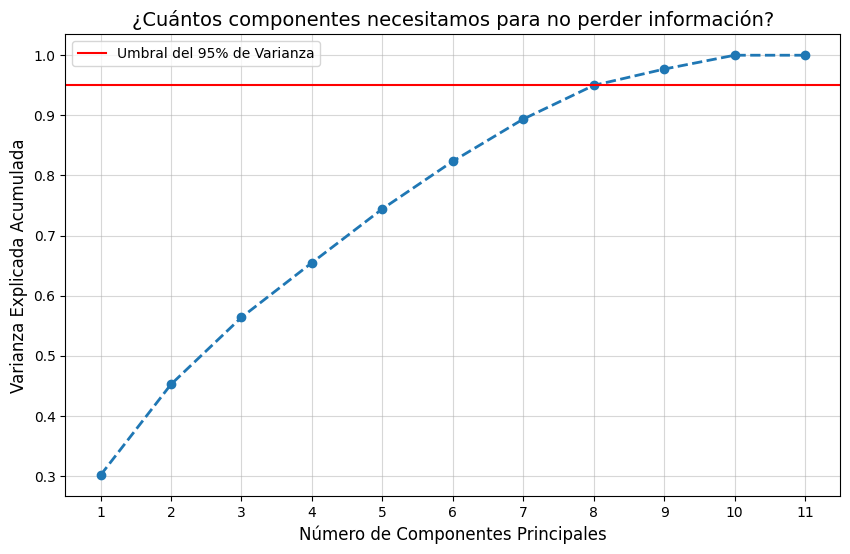

In [ ]:
# 1. Asegurarnos de usar tu matriz X exacta (las 12 variables de tu K-Means)
features_kmeans = [
    'has_sale', 'antiguedad_meses', 'age', 'gender_num', 'segment_num',
    'family_account_purchase', 'family_investment_purchase', 'family_loan_purchase',
    'family_payment_card_purchase', 'family_pension_plan_purchase', 'active_customer'
]
X_pca = df_segmentacion[features_kmeans].copy()

# 2. Escalar los datos (PASO VITAL: PCA es extremadamente sensible a las escalas)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# 3. Ajustar PCA pidiendo explícitamente que retenga el 95% de la varianza
pca_95 = PCA(n_components=0.95, random_state=42)
X_pca_transformed = pca_95.fit_transform(X_scaled)

# 4. Imprimir los resultados por pantalla
componentes_originales = X_pca.shape[1]
componentes_nuevos = pca_95.n_components_
varianza_explicada = np.sum(pca_95.explained_variance_ratio_) * 100

print("="*50)
print("📊 RESUMEN DEL ANÁLISIS PCA")
print("="*50)
print(f"Columnas numéricas originales introducidas: {componentes_originales}")
print(f"Componentes Principales creados para el modelo: {componentes_nuevos}")
print(f"Información (Varianza) total retenida: {varianza_explicada:.2f}%\n")

if componentes_nuevos < componentes_originales:
    print(f"💡 Éxito: Hemos reducido el modelo en {componentes_originales - componentes_nuevos} dimensiones.")
else:
    print("⚠️ Aviso: No hemos logrado reducir dimensiones manteniendo el 95% de la varianza.")

# 5. Visualización del codo (Scree Plot) para ver cómo se acumula la varianza
pca_full = PCA(random_state=42).fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(range(1, componentes_originales + 1), np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='-', label='Umbral del 95% de Varianza')
plt.title('¿Cuántos componentes necesitamos para no perder información?', fontsize=14)
plt.xlabel('Número de Componentes Principales', fontsize=12)
plt.ylabel('Varianza Explicada Acumulada', fontsize=12)
plt.xticks(range(1, componentes_originales + 1))
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

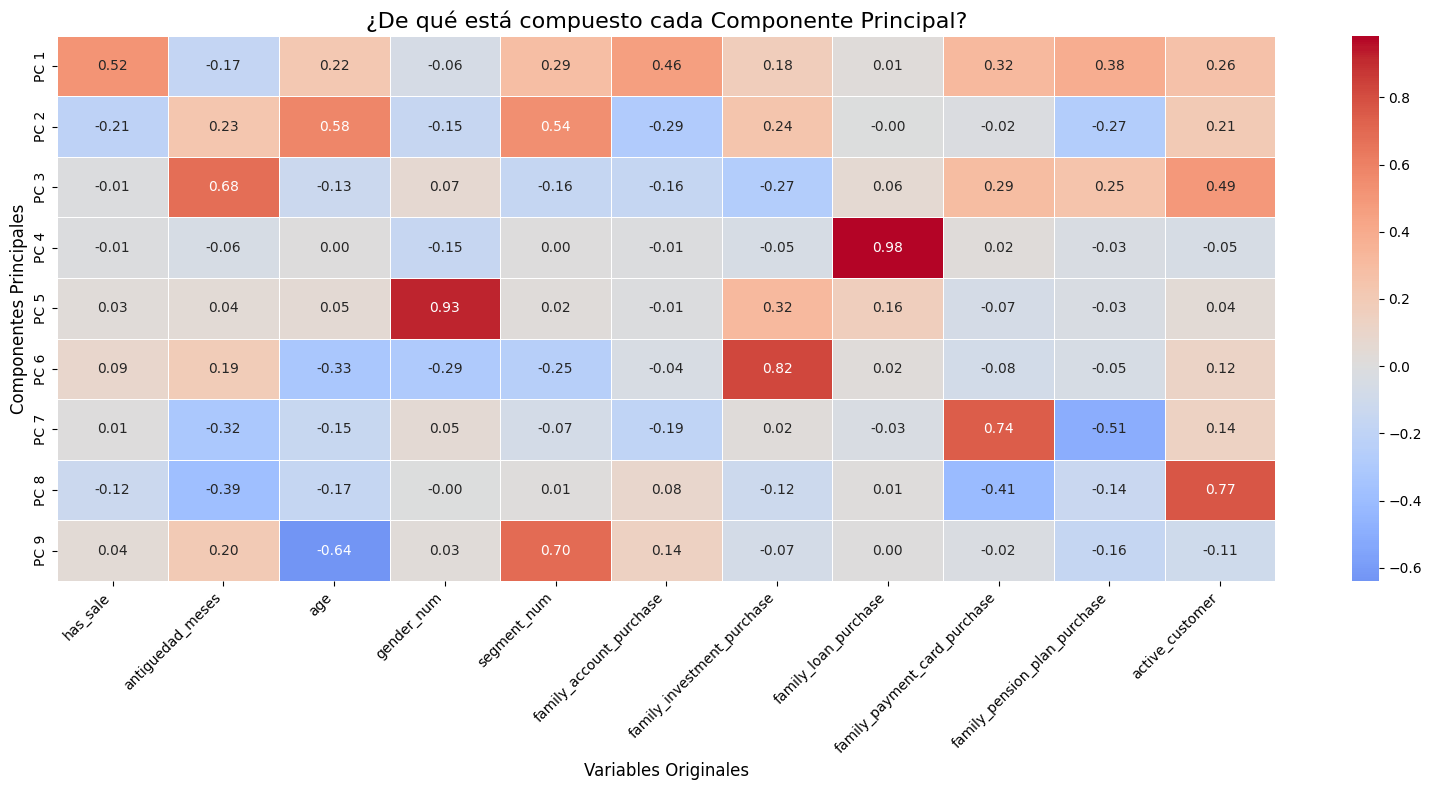

In [ ]:
# 1. Extraemos las cargas (loadings) del modelo pca_95
cargas = pca_95.components_

# 2. Lo metemos en un DataFrame para que sea legible
# features_kmeans viene de la celda anterior con los nombres de tus 12 columnas
df_cargas = pd.DataFrame(
    cargas,
    columns=features_kmeans,
    index=[f'PC {i+1}' for i in range(pca_95.n_components_)]
)

# 3. Pintamos el Mapa de Calor
plt.figure(figsize=(16, 8))
# Usamos 'coolwarm' centrado en 0 para ver rápidamente los polos opuestos
sns.heatmap(df_cargas, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5, center=0)
plt.title('¿De qué está compuesto cada Componente Principal?', fontsize=16)
plt.xlabel('Variables Originales', fontsize=12)
plt.ylabel('Componentes Principales', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Síntesis metodológica y conclusiones

El bloque final recoge la problemática inicial, la solución aplicada, el encaje tecnológico y una lectura estratégica de los resultados. Esta síntesis facilita la reutilización del notebook como evidencia metodológica dentro de la memoria del TFM y como soporte para la defensa.

## 1. Problemática: Segmentación de Clientes para Optimización Estratégica

Este apartado aborda la necesidad de comprender en profundidad la base de clientes de la entidad. La problemática central reside en la falta de una visión clara y diferenciada de los distintos perfiles de clientes, lo que dificulta la implementación de estrategias de marketing personalizadas, la gestión proactiva de la relación con el cliente (CRM) y la identificación de oportunidades de negocio específicas. El análisis busca resolver preguntas clave como: ¿quiénes son nuestros clientes más valiosos? ¿Qué segmentos presentan mayor potencial de crecimiento? ¿Qué productos son más atractivos para cada grupo? ¿Cómo podemos optimizar la rentabilidad de cada segmento?

## 2. Solución Aplicada: Clustering de Clientes con Preparación y Transformación de Datos

La solución implementada se enfoca en la segmentación de clientes mediante técnicas de clustering, combinando información sociodemográfica, comercial y de productos. El proceso se ha resuelto en varias etapas:

1.  **Integración y Limpieza de Datos**: Se consolidaron múltiples fuentes de datos (sociodemográficos, actividad comercial, productos y ventas) en un único *DataFrame* maestro (`df_master_t`). Se realizó una limpieza exhaustiva, eliminando columnas redundantes y gestionando valores nulos mediante imputación estratégica (mediana para `salary`, moda para variables categóricas como `gender`, `segment`, `region_code`, `payroll`, `pension_plan`).
2.  **Ingeniería de Características**: Se crearon nuevas variables clave como `months_since_entry` para medir la antigüedad del cliente y `province_segment` para categorizar provincias según el volumen de clientes, enriqueciendo así el perfil de cada individuo.
3.  **Clustering de Clientes (KMeans)**: Se aplicó el algoritmo de K-Means para agrupar a los clientes en segmentos homogéneos. Antes del clustering, los datos fueron preprocesados utilizando:
    *   `KNNImputer` para manejar nulos remanentes.
    *   `StandardScaler` para normalizar las características numéricas, asegurando que ninguna variable dominara el proceso de agrupamiento.
    *   `OneHotEncoder` para transformar las variables categóricas en un formato adecuado para el algoritmo.
4.  **Análisis de Componentes Principales (PCA)**: Se exploró el uso de PCA para reducir la dimensionalidad y simplificar el modelo, manteniendo el 95% de la varianza total. Aunque no se logró una reducción significativa en el número de componentes manteniendo este umbral, se incluyó en el pipeline para evaluar su impacto.
5.  **Perfilado de Clusters**: Cada clúster resultante fue perfilado detalladamente, analizando las características medias, medianas y modas de las variables originales. Esto permitió asignar nombres descriptivos a cada segmento (e.g., "Jóvenes universitarios con baja vinculación", "Clientes premium altamente rentables"), facilitando la comprensión y la toma de decisiones estratégicas.

## 4. Conclusiones de la Segmentación y Reducción de Dimensionalidad

Tras la fase de preprocesamiento y agregación de la serie temporal a nivel de cliente, se ha llevado a cabo un análisis de segmentación orientado a descubrir patrones de comportamiento subyacentes. La decisión metodológica de excluir variables puramente monetarias ha permitido eliminar el sesgo de magnitud económica, orientando el modelo hacia el **ciclo de vida y la vinculación real** del cliente.

Los resultados obtenidos permiten extraer las siguientes conclusiones académico-estratégicas:

### 4.1. Estructura de la Cartera: El Ciclo de Vida del Cliente
El algoritmo K-Means ha identificado seis perfiles de comportamiento claramente diferenciados. Para maximizar la interpretabilidad y adopción por parte de los equipos de negocio, se ha diseñado una taxonomía basada en la "calidad mineral" de la cartera, la cual mapea el estado del cliente en tres fases evolutivas:

* **Fase 1: Captación (Crecimiento potencial):** Agrupa a los clientes de reciente incorporación. Se divide entre perfiles muy jóvenes en fase de *onboarding* transaccional (**Esmeralda ❇️**, 23 años) y un nicho senior de alto patrimonio recién aterrizado con un enfoque exclusivo en productos de inversión (**Zafiro 🔵**, 50 años).
* **Fase 2: Consolidación (El núcleo rentable):** Representa a los clientes fuertemente fidelizados. Comprende tanto a la nueva generación de clientes principales con alta domiciliación de nóminas (**Rubí 🔴**, 27 años y 96% de actividad), como al cliente bancario tradicional acomodado, líder en el uso de tarjetas de crédito y vinculación a largo plazo (**Diamante 💎**, 53 años).
* **Fase 3: Abandono (La masa inactiva):** Aísla eficientemente el riesgo de fuga y el pasivo operativo de la entidad. Separa a los clientes antiguos que han perdido el interés y reducido drásticamente su actividad (**Circonita 🧊**) de aquellas cuentas "fantasma" sin uso ni contrataciones desde su apertura (**Cuarzo 🔮**).

### 4.2. Análisis de Componentes Principales (PCA) y Estructura Latente
Con el objetivo de evaluar la redundancia informativa de las variables originales, se ejecutó un Análisis de Componentes Principales (PCA). La necesidad de retener un alto número de componentes para explicar el 95% de la varianza demostró una baja colinealidad en el conjunto de datos.

El análisis de las cargas factoriales (*loadings*) confirmó que los comportamientos de los clientes son ortogonales; es decir, operan de forma independiente. Dimensiones como la transaccionalidad diaria (uso de cuentas y tarjetas), la especialización crediticia (préstamos) y la especialización en ahorro (fondos e inversión) aportan un valor informativo único que justifica su inclusión directa en el modelo de clustering sin compresión previa.

### 4.3. Implicaciones Estratégicas y Activación de Negocio (CRM)
Desde una perspectiva analítica y de operaciones, el uso de las variables originales junto a la segmentación K-Means de 6 clústeres resulta la solución óptima. La traslación de estos resultados métricos a una analogía de piedras preciosas resuelve uno de los mayores retos en *Data Science*: la interpretabilidad de negocio.

Esta segmentación proporciona a la entidad un mapa de acción directo para el diseño de campañas de CRM:
1. **Campañas de Retención y Cross-selling:** Dirigidas a rentabilizar a los *Zafiros* y mantener la excelencia en los *Diamantes* y *Rubíes*.
2. **Estrategias de Onboarding:** Fomentar la digitalización y vinculación temprana de las *Esmeraldas* antes de que su interés decaiga.
3. **Planes de Eficiencia Operativa:** Lanzar planes de reactivación agresivos sobre las *Circonitas* y evaluar el cierre progresivo de las cuentas de nivel *Cuarzo* para reducir los costes de infraestructura del banco.